In [179]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("50_Startups.csv")

# Convert categorical 'State' into dummy variables
df = pd.get_dummies(df, columns=['State'], drop_first=True)

# Define Features (X) and Target (y)
X = df.drop(columns=['Profit'])  # Feature variables
y = df['Profit']  # Target variable (what we want to predict)








In [180]:
# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


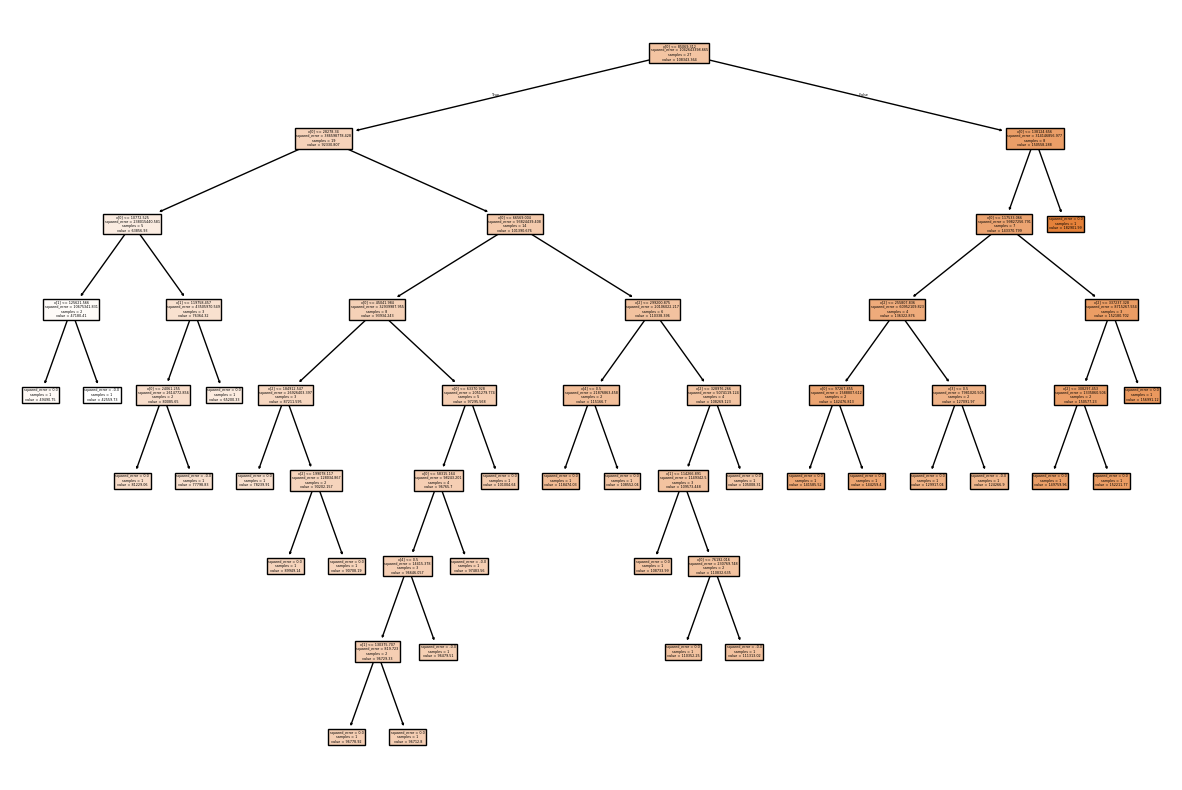

In [181]:
%matplotlib inline

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=6, criterion='squared_error', random_state=42)
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)



# Plot the trained Decision Tree

plt.figure(figsize=(15, 10))
plot_tree(regressor.estimators_[0], filled=True)
plt.show()




In [182]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 34472280.79226219
R² Score: 0.957430701149123


In [183]:
import pickle

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(regressor, f)

#load the model
with open('rf_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)